In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

np.random.seed(42)

In [2]:
n = 5000

lead_ids = [f"LEAD{10001+i}" for i in range(n)]

dates = pd.date_range(
    start="2024-01-01",
    end="2025-12-31",
    freq="D"
)

channels = [
    "Organic Search",
    "Paid Search",
    "Social Media",
    "Email",
    "Referral",
    "Display Ads"
]

campaigns = [
    "Brand Awareness",
    "Product Launch",
    "Summer Campaign",
    "Festive Offer",
    "Free Trial",
    "Retargeting"
]

devices = ["Desktop", "Mobile", "Tablet"]

regions = ["North", "South", "East", "West"]

funnel = pd.DataFrame({
    "Lead ID": lead_ids,
    "Date": np.random.choice(dates, n),
    "Channel": np.random.choice(
        channels,
        n,
        p=[0.22, 0.20, 0.18, 0.14, 0.16, 0.10]
    ),
    "Campaign": np.random.choice(
        campaigns,
        n
    ),
    "Device": np.random.choice(
        devices,
        n,
        p=[0.45, 0.45, 0.10]
    ),
    "Region": np.random.choice(
        regions,
        n
    )
})

funnel.head()

,Lead ID,Date,Channel,Campaign,Device,Region
0,LEAD10001,2024-04-12,Organic Search,Retargeting,Desktop,East
1,LEAD10002,2025-03-11,Paid Search,Summer Campaign,Tablet,West
2,LEAD10003,2024-09-27,Referral,Festive Offer,Tablet,East
3,LEAD10004,2024-04-16,Organic Search,Retargeting,Tablet,West
4,LEAD10005,2024-03-12,Organic Search,Festive Offer,Mobile,West


In [3]:
channel_quality = funnel["Channel"].map({
    "Organic Search": 0.75,
    "Paid Search": 0.68,
    "Social Media": 0.48,
    "Email": 0.72,
    "Referral": 0.82,
    "Display Ads": 0.38
})

campaign_effect = funnel["Campaign"].map({
    "Brand Awareness": 0.90,
    "Product Launch": 1.05,
    "Summer Campaign": 0.95,
    "Festive Offer": 1.10,
    "Free Trial": 1.15,
    "Retargeting": 1.08
})

device_effect = funnel["Device"].map({
    "Desktop": 1.05,
    "Mobile": 0.92,
    "Tablet": 0.85
})

lead_probability = np.clip(
    0.32 * channel_quality
    * campaign_effect
    * device_effect,
    0.05,
    0.75
)

funnel["Visitor"] = 1

funnel["Lead"] = (
    np.random.random(n) < lead_probability
).astype(int)

qualification_probability = np.clip(
    0.62 * channel_quality
    * campaign_effect,
    0.10,
    0.85
)

funnel["Qualified Lead"] = (
    (funnel["Lead"] == 1) &
    (np.random.random(n) < qualification_probability)
).astype(int)

opportunity_probability = np.clip(
    0.58 * channel_quality
    * campaign_effect,
    0.08,
    0.80
)

funnel["Opportunity"] = (
    (funnel["Qualified Lead"] == 1) &
    (np.random.random(n) < opportunity_probability)
).astype(int)

customer_probability = np.clip(
    0.52 * channel_quality
    * campaign_effect,
    0.05,
    0.75
)

funnel["Customer"] = (
    (funnel["Opportunity"] == 1) &
    (np.random.random(n) < customer_probability)
).astype(int)

funnel["Revenue"] = np.where(
    funnel["Customer"] == 1,
    np.random.randint(500, 5001, n),
    0
)

funnel.head()

,Lead ID,Date,Channel,Campaign,Device,Region,Visitor,Lead,Qualified Lead,Opportunity,Customer,Revenue
0,LEAD10001,2024-04-12,Organic Search,Retargeting,Desktop,East,1,0,0,0,0,0
1,LEAD10002,2025-03-11,Paid Search,Summer Campaign,Tablet,West,1,0,0,0,0,0
2,LEAD10003,2024-09-27,Referral,Festive Offer,Tablet,East,1,0,0,0,0,0
3,LEAD10004,2024-04-16,Organic Search,Retargeting,Tablet,West,1,0,0,0,0,0
4,LEAD10005,2024-03-12,Organic Search,Festive Offer,Mobile,West,1,0,0,0,0,0


In [4]:
funnel["Date"] = pd.to_datetime(funnel["Date"])

funnel["Month"] = (
    funnel["Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

funnel["Year"] = funnel["Date"].dt.year

funnel["Lead Status"] = np.select(
    [
        funnel["Customer"] == 1,
        funnel["Opportunity"] == 1,
        funnel["Qualified Lead"] == 1,
        funnel["Lead"] == 1
    ],
    [
        "Customer",
        "Opportunity",
        "Qualified Lead",
        "Lead"
    ],
    default="Visitor"
)

print("Rows:", len(funnel))
print("Duplicate rows:", funnel.duplicated().sum())
print("Missing values:", funnel.isnull().sum().sum())

display(funnel.head())

Rows: 5000
Duplicate rows: 0
Missing values: 0


,Lead ID,Date,Channel,Campaign,Device,Region,Visitor,Lead,Qualified Lead,Opportunity,Customer,Revenue,Month,Year,Lead Status
0,LEAD10001,2024-04-12,Organic Search,Retargeting,Desktop,East,1,0,0,0,0,0,2024-04-01,2024,Visitor
1,LEAD10002,2025-03-11,Paid Search,Summer Campaign,Tablet,West,1,0,0,0,0,0,2025-03-01,2025,Visitor
2,LEAD10003,2024-09-27,Referral,Festive Offer,Tablet,East,1,0,0,0,0,0,2024-09-01,2024,Visitor
3,LEAD10004,2024-04-16,Organic Search,Retargeting,Tablet,West,1,0,0,0,0,0,2024-04-01,2024,Visitor
4,LEAD10005,2024-03-12,Organic Search,Festive Offer,Mobile,West,1,0,0,0,0,0,2024-03-01,2024,Visitor


In [5]:
# Cell 5 — Funnel Metrics & Performance Analysis

# Overall funnel metrics
total_visitors = funnel["Visitor"].sum()
total_leads = funnel["Lead"].sum()
total_qualified = funnel["Qualified Lead"].sum()
total_opportunities = funnel["Opportunity"].sum()
total_customers = funnel["Customer"].sum()
total_revenue = funnel["Revenue"].sum()

traffic_to_lead = total_leads / total_visitors * 100
lead_to_qualified = total_qualified / total_leads * 100 if total_leads > 0 else 0
qualified_to_opportunity = (
    total_opportunities / total_qualified * 100
    if total_qualified > 0 else 0
)
opportunity_to_customer = (
    total_customers / total_opportunities * 100
    if total_opportunities > 0 else 0
)
visitor_to_customer = total_customers / total_visitors * 100

funnel_metrics = pd.DataFrame({
    "Funnel Stage": [
        "Visitors",
        "Leads",
        "Qualified Leads",
        "Opportunities",
        "Customers"
    ],
    "Count": [
        total_visitors,
        total_leads,
        total_qualified,
        total_opportunities,
        total_customers
    ]
})

funnel_metrics["Conversion from Previous Stage (%)"] = [
    100,
    traffic_to_lead,
    lead_to_qualified,
    qualified_to_opportunity,
    opportunity_to_customer
]

funnel_metrics["Drop-off from Previous Stage"] = [
    0,
    total_visitors - total_leads,
    total_leads - total_qualified,
    total_qualified - total_opportunities,
    total_opportunities - total_customers
]

print("OVERALL FUNNEL PERFORMANCE")
display(funnel_metrics.round(2))

print(f"\nOverall Visitor-to-Customer Conversion: {visitor_to_customer:.2f}%")
print(f"Total Revenue Generated: {total_revenue:,.2f}")


# Channel performance
channel_analysis = funnel.groupby("Channel").agg(
    Visitors=("Visitor", "sum"),
    Leads=("Lead", "sum"),
    Qualified_Leads=("Qualified Lead", "sum"),
    Opportunities=("Opportunity", "sum"),
    Customers=("Customer", "sum"),
    Revenue=("Revenue", "sum")
)

channel_analysis["Visitor-to-Lead (%)"] = (
    channel_analysis["Leads"]
    / channel_analysis["Visitors"] * 100
)

channel_analysis["Lead-to-Customer (%)"] = (
    channel_analysis["Customers"]
    / channel_analysis["Leads"] * 100
)

channel_analysis["Visitor-to-Customer (%)"] = (
    channel_analysis["Customers"]
    / channel_analysis["Visitors"] * 100
)

print("\nCHANNEL PERFORMANCE")
display(channel_analysis.round(2))


# Campaign performance
campaign_analysis = funnel.groupby("Campaign").agg(
    Visitors=("Visitor", "sum"),
    Leads=("Lead", "sum"),
    Qualified_Leads=("Qualified Lead", "sum"),
    Opportunities=("Opportunity", "sum"),
    Customers=("Customer", "sum"),
    Revenue=("Revenue", "sum")
)

campaign_analysis["Visitor-to-Lead (%)"] = (
    campaign_analysis["Leads"]
    / campaign_analysis["Visitors"] * 100
)

campaign_analysis["Lead-to-Customer (%)"] = (
    campaign_analysis["Customers"]
    / campaign_analysis["Leads"] * 100
)

campaign_analysis["Visitor-to-Customer (%)"] = (
    campaign_analysis["Customers"]
    / campaign_analysis["Visitors"] * 100
)

print("\nCAMPAIGN PERFORMANCE")
display(campaign_analysis.round(2))


# Monthly performance
monthly_analysis = funnel.groupby("Month").agg(
    Visitors=("Visitor", "sum"),
    Leads=("Lead", "sum"),
    Qualified_Leads=("Qualified Lead", "sum"),
    Opportunities=("Opportunity", "sum"),
    Customers=("Customer", "sum"),
    Revenue=("Revenue", "sum")
)

monthly_analysis["Visitor-to-Lead (%)"] = (
    monthly_analysis["Leads"]
    / monthly_analysis["Visitors"] * 100
)

monthly_analysis["Visitor-to-Customer (%)"] = (
    monthly_analysis["Customers"]
    / monthly_analysis["Visitors"] * 100
)

print("\nMONTHLY PERFORMANCE")
display(monthly_analysis.round(2))


# Device performance
device_analysis = funnel.groupby("Device").agg(
    Visitors=("Visitor", "sum"),
    Leads=("Lead", "sum"),
    Customers=("Customer", "sum"),
    Revenue=("Revenue", "sum")
)

device_analysis["Visitor-to-Lead (%)"] = (
    device_analysis["Leads"]
    / device_analysis["Visitors"] * 100
)

device_analysis["Visitor-to-Customer (%)"] = (
    device_analysis["Customers"]
    / device_analysis["Visitors"] * 100
)

print("\nDEVICE PERFORMANCE")
display(device_analysis.round(2))

OVERALL FUNNEL PERFORMANCE


,Funnel Stage,Count,Conversion from Previous Stage (%),Drop-off from Previous Stage
0,Visitors,5000,100.00,0
1,Leads,1003,20.06,3997
2,Qualified Leads,438,43.67,565
3,Opportunities,190,43.38,248
4,Customers,84,44.21,106



Overall Visitor-to-Customer Conversion: 1.68%
Total Revenue Generated: 249,527.00

CHANNEL PERFORMANCE


,Visitors,Leads,Qualified_Leads,Opportunities,Customers,Revenue,Visitor-to-Lead (%),Lead-to-Customer (%),Visitor-to-Customer (%)
Channel,,,,,,,,,
Display Ads,493,77,23,7,1,3738,15.62,1.30,0.20
Email,656,138,64,28,9,25960,21.04,6.52,1.37
Organic Search,1138,250,121,60,28,76513,21.97,11.20,2.46
Paid Search,1034,216,83,31,15,53089,20.89,6.94,1.45
Referral,748,199,107,49,25,72401,26.60,12.56,3.34
Social Media,931,123,40,15,6,17826,13.21,4.88,0.64



CAMPAIGN PERFORMANCE


,Visitors,Leads,Qualified_Leads,Opportunities,Customers,Revenue,Visitor-to-Lead (%),Lead-to-Customer (%),Visitor-to-Customer (%)
Campaign,,,,,,,,,
Brand Awareness,807,143,50,20,8,23555,17.72,5.59,0.99
Festive Offer,880,186,82,41,21,59165,21.14,11.29,2.39
Free Trial,843,196,89,36,13,38491,23.25,6.63,1.54
Product Launch,850,181,90,34,17,55857,21.29,9.39,2.00
Retargeting,843,152,69,31,15,42711,18.03,9.87,1.78
Summer Campaign,777,145,58,28,10,29748,18.66,6.90,1.29



MONTHLY PERFORMANCE


,Visitors,Leads,Qualified_Leads,Opportunities,Customers,Revenue,Visitor-to-Lead (%),Visitor-to-Customer (%)
Month,,,,,,,,
2024-01-01,214,45,19,6,1,677,21.03,0.47
2024-02-01,192,39,13,7,3,8507,20.31,1.56
2024-03-01,204,39,16,6,3,10041,19.12,1.47
2024-04-01,221,55,28,14,3,8911,24.89,1.36
2024-05-01,209,37,14,5,2,6433,17.70,0.96
2024-06-01,207,41,18,8,6,22620,19.81,2.90
2024-07-01,206,33,13,4,2,6538,16.02,0.97
2024-08-01,216,40,14,8,4,12549,18.52,1.85
2024-09-01,192,44,21,10,6,18050,22.92,3.12



DEVICE PERFORMANCE


,Visitors,Leads,Customers,Revenue,Visitor-to-Lead (%),Visitor-to-Customer (%)
Device,,,,,,
Desktop,2253,478,43,138197,21.22,1.91
Mobile,2244,439,32,87697,19.56,1.43
Tablet,503,86,9,23633,17.10,1.79


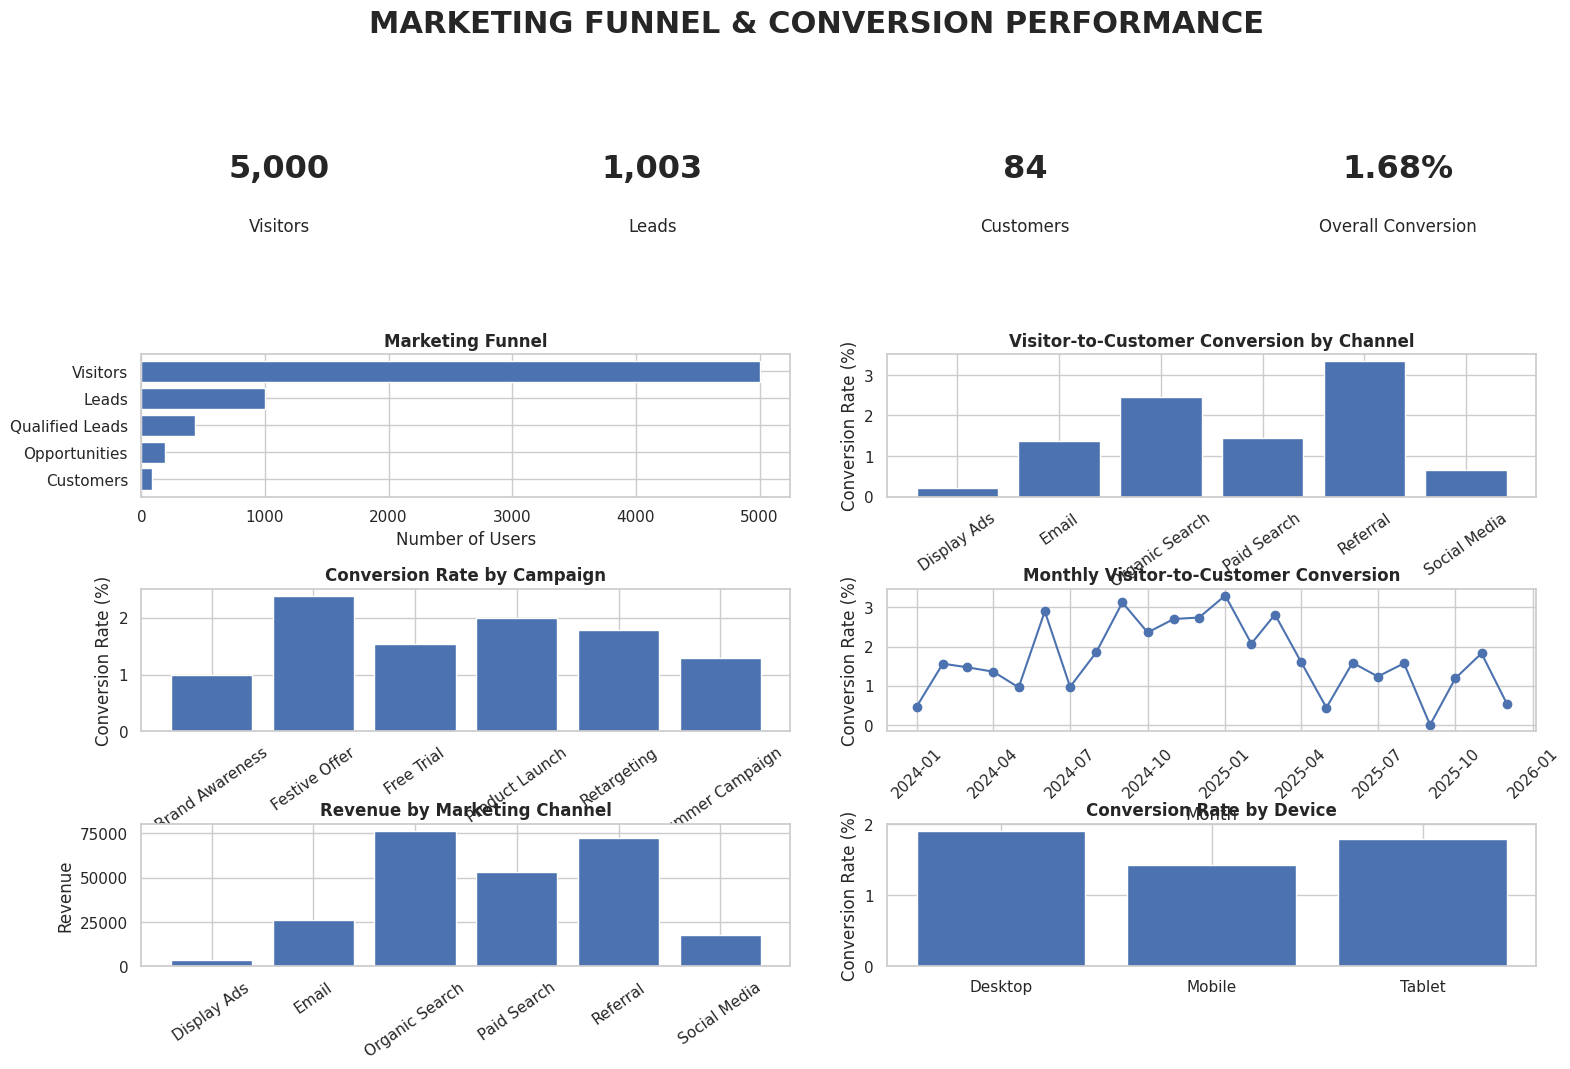

FUNNEL SUMMARY


,Stage,Users,Conversion Rate (%),Drop-off,Drop-off Rate (%)
0,Visitors,5000,100.00,0,0.00
1,Leads,1003,20.06,3997,79.94
2,Qualified Leads,438,43.67,565,56.33
3,Opportunities,190,43.38,248,56.62
4,Customers,84,44.21,106,55.79



KEY BUSINESS INSIGHTS
-------------------------------------------------------
1. Overall visitor-to-customer conversion is 1.68%.
2. The largest percentage drop-off occurs at the Leads stage, with a drop-off of 79.94%.
3. Referral has the highest visitor-to-customer conversion rate at 3.34%.
4. Festive Offer has the highest visitor-to-customer conversion rate at 2.39%.
5. Desktop shows the highest visitor-to-customer conversion rate at 1.91%.
6. Organic Search generates the highest channel revenue of 76,513.00.
7. Festive Offer generates the highest campaign revenue of 59,165.00.
8. Average revenue per acquired customer is 2,970.56.

All project files have been created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# Cell 6 — Final Dashboard, Insights & Project Files

from matplotlib.gridspec import GridSpec

# -----------------------------
# Key calculations
# -----------------------------

stage_names = [
    "Visitors",
    "Leads",
    "Qualified Leads",
    "Opportunities",
    "Customers"
]

stage_counts = [
    total_visitors,
    total_leads,
    total_qualified,
    total_opportunities,
    total_customers
]

conversion_rates = [
    100,
    traffic_to_lead,
    lead_to_qualified,
    qualified_to_opportunity,
    opportunity_to_customer
]

drop_offs = [
    0,
    total_visitors - total_leads,
    total_leads - total_qualified,
    total_qualified - total_opportunities,
    total_opportunities - total_customers
]

# Find largest percentage drop
drop_rates = [
    0,
    100 - traffic_to_lead,
    100 - lead_to_qualified,
    100 - qualified_to_opportunity,
    100 - opportunity_to_customer
]

largest_drop_index = np.argmax(drop_rates[1:]) + 1
largest_drop_stage = stage_names[largest_drop_index]
largest_drop_rate = drop_rates[largest_drop_index]

best_channel = channel_analysis["Visitor-to-Customer (%)"].idxmax()
best_channel_conversion = channel_analysis.loc[
    best_channel, "Visitor-to-Customer (%)"
]

best_campaign = campaign_analysis["Visitor-to-Customer (%)"].idxmax()
best_campaign_conversion = campaign_analysis.loc[
    best_campaign, "Visitor-to-Customer (%)"
]

best_device = device_analysis["Visitor-to-Customer (%)"].idxmax()
best_device_conversion = device_analysis.loc[
    best_device, "Visitor-to-Customer (%)"
]

highest_revenue_channel = channel_analysis["Revenue"].idxmax()
highest_channel_revenue = channel_analysis.loc[
    highest_revenue_channel, "Revenue"
]

highest_revenue_campaign = campaign_analysis["Revenue"].idxmax()
highest_campaign_revenue = campaign_analysis.loc[
    highest_revenue_campaign, "Revenue"
]

average_customer_value = (
    total_revenue / total_customers
    if total_customers > 0 else 0
)

# -----------------------------
# Funnel Dashboard
# -----------------------------

fig = plt.figure(figsize=(18, 11))

gs = GridSpec(
    4, 4,
    figure=fig,
    hspace=0.65,
    wspace=0.35
)

fig.suptitle(
    "MARKETING FUNNEL & CONVERSION PERFORMANCE",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

# KPI cards
dashboard_kpis = [
    ("Visitors", f"{total_visitors:,}"),
    ("Leads", f"{total_leads:,}"),
    ("Customers", f"{total_customers:,}"),
    ("Overall Conversion", f"{visitor_to_customer:.2f}%")
]

for i, (title, value) in enumerate(dashboard_kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.axis("off")

    ax.text(
        0.5, 0.65,
        value,
        ha="center",
        va="center",
        fontsize=23,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        title,
        ha="center",
        va="center",
        fontsize=12
    )

# Funnel chart
ax1 = fig.add_subplot(gs[1, :2])

ax1.barh(
    stage_names[::-1],
    stage_counts[::-1]
)

ax1.set_title(
    "Marketing Funnel",
    fontweight="bold"
)

ax1.set_xlabel("Number of Users")

# Channel conversion
ax2 = fig.add_subplot(gs[1, 2:])

ax2.bar(
    channel_analysis.index,
    channel_analysis["Visitor-to-Customer (%)"]
)

ax2.set_title(
    "Visitor-to-Customer Conversion by Channel",
    fontweight="bold"
)

ax2.set_ylabel("Conversion Rate (%)")
ax2.tick_params(axis="x", rotation=35)

# Campaign conversion
ax3 = fig.add_subplot(gs[2, :2])

ax3.bar(
    campaign_analysis.index,
    campaign_analysis["Visitor-to-Customer (%)"]
)

ax3.set_title(
    "Conversion Rate by Campaign",
    fontweight="bold"
)

ax3.set_ylabel("Conversion Rate (%)")
ax3.tick_params(axis="x", rotation=35)

# Monthly conversion trend
ax4 = fig.add_subplot(gs[2, 2:])

ax4.plot(
    monthly_analysis.index,
    monthly_analysis["Visitor-to-Customer (%)"],
    marker="o"
)

ax4.set_title(
    "Monthly Visitor-to-Customer Conversion",
    fontweight="bold"
)

ax4.set_xlabel("Month")
ax4.set_ylabel("Conversion Rate (%)")
ax4.tick_params(axis="x", rotation=45)

# Revenue by channel
ax5 = fig.add_subplot(gs[3, :2])

ax5.bar(
    channel_analysis.index,
    channel_analysis["Revenue"]
)

ax5.set_title(
    "Revenue by Marketing Channel",
    fontweight="bold"
)

ax5.set_ylabel("Revenue")
ax5.tick_params(axis="x", rotation=35)

# Device performance
ax6 = fig.add_subplot(gs[3, 2:])

ax6.bar(
    device_analysis.index,
    device_analysis["Visitor-to-Customer (%)"]
)

ax6.set_title(
    "Conversion Rate by Device",
    fontweight="bold"
)

ax6.set_ylabel("Conversion Rate (%)")

plt.savefig(
    "Marketing_Funnel_Dashboard.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# Funnel summary table
# -----------------------------

funnel_summary = pd.DataFrame({
    "Stage": stage_names,
    "Users": stage_counts,
    "Conversion Rate (%)": conversion_rates,
    "Drop-off": drop_offs,
    "Drop-off Rate (%)": drop_rates
})

print("FUNNEL SUMMARY")
display(funnel_summary.round(2))


# -----------------------------
# Business insights
# -----------------------------

print("\nKEY BUSINESS INSIGHTS")
print("-" * 55)

print(
    f"1. Overall visitor-to-customer conversion is "
    f"{visitor_to_customer:.2f}%."
)

print(
    f"2. The largest percentage drop-off occurs at the "
    f"{largest_drop_stage} stage, with a drop-off of "
    f"{largest_drop_rate:.2f}%."
)

print(
    f"3. {best_channel} has the highest visitor-to-customer "
    f"conversion rate at {best_channel_conversion:.2f}%."
)

print(
    f"4. {best_campaign} has the highest visitor-to-customer "
    f"conversion rate at {best_campaign_conversion:.2f}%."
)

print(
    f"5. {best_device} shows the highest visitor-to-customer "
    f"conversion rate at {best_device_conversion:.2f}%."
)

print(
    f"6. {highest_revenue_channel} generates the highest "
    f"channel revenue of {highest_channel_revenue:,.2f}."
)

print(
    f"7. {highest_revenue_campaign} generates the highest "
    f"campaign revenue of {highest_campaign_revenue:,.2f}."
)

print(
    f"8. Average revenue per acquired customer is "
    f"{average_customer_value:,.2f}."
)


# -----------------------------
# Excel workbook
# -----------------------------

with pd.ExcelWriter(
    "Marketing_Funnel_Analysis.xlsx",
    engine="openpyxl"
) as writer:

    funnel.to_excel(
        writer,
        sheet_name="Funnel Data",
        index=False
    )

    funnel_summary.to_excel(
        writer,
        sheet_name="Funnel Summary",
        index=False
    )

    channel_analysis.reset_index().to_excel(
        writer,
        sheet_name="Channel Analysis",
        index=False
    )

    campaign_analysis.reset_index().to_excel(
        writer,
        sheet_name="Campaign Analysis",
        index=False
    )

    monthly_analysis.reset_index().to_excel(
        writer,
        sheet_name="Monthly Analysis",
        index=False
    )

    device_analysis.reset_index().to_excel(
        writer,
        sheet_name="Device Analysis",
        index=False
    )


# -----------------------------
# Analysis report
# -----------------------------

report = f"""
MARKETING FUNNEL & CONVERSION PERFORMANCE ANALYSIS
==================================================

1. PROJECT OVERVIEW
-------------------
This project analyzes marketing funnel data to understand how users move
from visitors to leads, qualified leads, opportunities, and customers.

The analysis evaluates conversion rates, drop-off points, marketing
channels, campaigns, devices, revenue performance, and monthly trends.

The dataset contains {len(funnel):,} records.

2. KEY PERFORMANCE INDICATORS
-----------------------------
Total Visitors: {total_visitors:,}
Total Leads: {total_leads:,}
Qualified Leads: {total_qualified:,}
Opportunities: {total_opportunities:,}
Customers: {total_customers:,}

Visitor-to-Lead Conversion: {traffic_to_lead:.2f}%
Lead-to-Qualified Conversion: {lead_to_qualified:.2f}%
Qualified-to-Opportunity Conversion: {qualified_to_opportunity:.2f}%
Opportunity-to-Customer Conversion: {opportunity_to_customer:.2f}%
Overall Visitor-to-Customer Conversion: {visitor_to_customer:.2f}%

Total Revenue: {total_revenue:,.2f}
Average Revenue per Customer: {average_customer_value:,.2f}

3. FUNNEL DROP-OFF ANALYSIS
---------------------------
The largest percentage drop-off occurs at the
{largest_drop_stage} stage.

The observed drop-off rate at this stage is
{largest_drop_rate:.2f}%.

This stage represents an important opportunity for conversion optimization.

4. CHANNEL PERFORMANCE
----------------------
The channel with the highest observed visitor-to-customer conversion is
{best_channel}, with a conversion rate of
{best_channel_conversion:.2f}%.

The channel generating the highest total revenue is
{highest_revenue_channel}, with revenue of
{highest_channel_revenue:,.2f}.

5. CAMPAIGN PERFORMANCE
-----------------------
The campaign with the highest observed visitor-to-customer conversion is
{best_campaign}, with a conversion rate of
{best_campaign_conversion:.2f}%.

The campaign generating the highest revenue is
{highest_revenue_campaign}, with revenue of
{highest_campaign_revenue:,.2f}.

6. DEVICE PERFORMANCE
---------------------
The device with the highest observed visitor-to-customer conversion is
{best_device}, at {best_device_conversion:.2f}%.

Device-level differences can help identify opportunities for landing-page
and user-experience optimization.

7. RECOMMENDATIONS
------------------
1. Focus optimization efforts on the funnel stage with the largest
   observed drop-off.

2. Improve landing pages and calls-to-action to increase visitor-to-lead
   conversion.

3. Strengthen lead qualification and follow-up processes to improve the
   transition from leads to qualified leads.

4. Compare high-converting channels with high-volume channels to improve
   marketing budget allocation.

5. Replicate successful campaign characteristics across future campaigns.

6. Optimize the customer journey for devices showing lower conversion.

7. Use monthly funnel monitoring to identify changes in conversion
   performance and respond quickly to emerging drop-offs.

8. Combine conversion performance with revenue data when evaluating
   marketing channel effectiveness.

8. BUSINESS VALUE
-----------------
The analysis provides a structured view of the customer acquisition funnel
and highlights where potential improvements can increase lead and customer
conversion.

The dashboard and supporting analysis can be used by marketing,
sales, growth, and business teams to monitor funnel performance and
prioritize conversion optimization activities.

Note: The dataset used in this project is simulated for analytical and
demonstration purposes.
"""

with open(
    "Marketing_Funnel_Analysis_Report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)


# -----------------------------
# README
# -----------------------------

readme = f"""# Marketing Funnel & Conversion Performance Analysis

## Project Overview

This project analyzes marketing funnel data to identify conversion
drop-offs, channel performance, campaign effectiveness, and opportunities
to improve lead-to-customer conversion.

## Objectives

- Analyze visitor-to-lead conversion
- Measure lead-to-customer conversion
- Identify major funnel drop-offs
- Compare marketing channels
- Compare campaign performance
- Analyze monthly conversion trends
- Evaluate device-level conversion
- Analyze marketing revenue
- Provide actionable recommendations

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Excel

## Key Metrics

- Total Visitors: {total_visitors:,}
- Total Leads: {total_leads:,}
- Total Customers: {total_customers:,}
- Visitor-to-Lead Conversion: {traffic_to_lead:.2f}%
- Overall Visitor-to-Customer Conversion: {visitor_to_customer:.2f}%
- Total Revenue: {total_revenue:,.2f}

## Analysis Areas

1. Funnel Stage Conversion
2. Funnel Drop-off Analysis
3. Marketing Channel Performance
4. Campaign Performance
5. Monthly Conversion Trends
6. Device Performance
7. Revenue Analysis
8. Business Recommendations

## Deliverables

- Marketing_Funnel_Dashboard.png
- Marketing_Funnel_Analysis.xlsx
- Marketing_Funnel_Analysis_Report.txt
- README.md
- Marketing_Funnel_Analysis.ipynb

## Business Recommendations

- Optimize the highest drop-off stage
- Improve landing pages and calls-to-action
- Strengthen lead qualification and follow-up
- Analyze channel quality alongside volume
- Replicate successful campaign strategies
- Improve device-specific user experience
- Monitor funnel performance monthly

## Dataset

The dataset is simulated for analytical and demonstration purposes.
"""

with open(
    "README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)


print("\nAll project files have been created successfully.")

# Download dashboard
from google.colab import files

files.download("Marketing_Funnel_Dashboard.png")

In [7]:
from google.colab import files

files.download("Marketing_Funnel_Analysis.xlsx")
files.download("Marketing_Funnel_Analysis_Report.txt")
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>